In [10]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI

In [11]:
from langgraph.graph.message import add_messages

class ChatState(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages]

In [12]:

load_dotenv(override=True)
import os


In [13]:
def get_groq_llm():
    return ChatOpenAI(
        model="openai/gpt-oss-20b",
        base_url="https://api.groq.com/openai/v1",
        api_key=os.getenv("GROQ_API_KEY"),
        temperature=0.7, max_tokens=2000
    )

llm = get_groq_llm()

In [14]:
llm.invoke("hloo")

AIMessage(content='Hi there! 👋 How can I help you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 61, 'prompt_tokens': 73, 'total_tokens': 134, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 40, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': None, 'queue_time': 0.052664944, 'prompt_time': 0.004087565, 'completion_time': 0.061313851, 'total_time': 0.065401416}, 'model_provider': 'openai', 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_80501ff3a1', 'id': 'chatcmpl-40a2bcdf-f3c2-41d5-861a-599ee38a30e9', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e3f10-00f7-7961-b36b-07f937718ad6-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 73, 'output_tokens': 61, 'total_tokens': 134, 'input_token_details': {}, 'output_token_details': {'reasoning': 40}})

In [15]:
def chat_node(state: ChatState):

    # take user query from state
    messages = state['messages']

    # send to llm
    response = llm.invoke(messages)

    # response store state
    return {'messages': [response]}

In [16]:
graph = StateGraph(ChatState)

# add nodes
graph.add_node('chat_node', chat_node)

graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

chatbot = graph.compile()

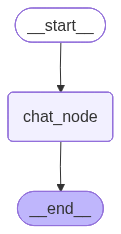

In [17]:
chatbot

In [18]:
initial_state = {
    'messages': [HumanMessage(content='What is the capital of india')]
}

chatbot.invoke(initial_state)


{'messages': [HumanMessage(content='What is the capital of india', additional_kwargs={}, response_metadata={}, id='1104f7d6-adb4-4a3f-9ef5-872c98e6edfd'),
  AIMessage(content='The capital of India is **New Delhi**.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 40, 'prompt_tokens': 77, 'total_tokens': 117, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 21, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': None, 'queue_time': 0.051853792, 'prompt_time': 0.004289448, 'completion_time': 0.041604829, 'total_time': 0.045894277}, 'model_provider': 'openai', 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_5c8ca06ea1', 'id': 'chatcmpl-ec4b9e3b-d0ed-483f-ac7a-08d6037bdf48', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e3f10-2a17-7d00-8734-bcf4b53010ad-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_toke

In [19]:
initial_state = {
    'messages': [HumanMessage(content='HI there my name is sachin, How are you doing today?')]
}

chatbot.invoke(initial_state)

{'messages': [HumanMessage(content='HI there my name is sachin, How are you doing today?', additional_kwargs={}, response_metadata={}, id='405c3926-d584-4d41-b74a-d7aa5a6c7ed7'),
  AIMessage(content='Hello Sachin! I’m doing great—thanks for asking. How about you? Anything interesting on your mind today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 93, 'prompt_tokens': 85, 'total_tokens': 178, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 60, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': None, 'queue_time': 0.049392188, 'prompt_time': 0.004697532, 'completion_time': 0.095690509, 'total_time': 0.100388041}, 'model_provider': 'openai', 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_5c8ca06ea1', 'id': 'chatcmpl-6f735c5e-b800-4d8e-9334-2d4a1a88b35d', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e3f10-3919-77

In [20]:
initial_state = {
    'messages': [HumanMessage(content='Hey do you remember my name?')]
}

chatbot.invoke(initial_state)['messages'][-1].content


'I’m not sure—I don’t have that information saved. Could you remind me of your name?'

# ## Let's add memory


In [21]:
from langgraph.checkpoint.memory import InMemorySaver

In [22]:
graph = StateGraph(ChatState)

# add nodes
graph.add_node('chat_node', chat_node)

graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)




In [23]:
checkpointer = InMemorySaver()

chatbot = graph.compile(checkpointer=checkpointer)

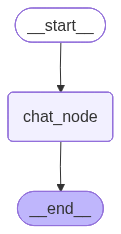

In [24]:
chatbot

In [25]:
config = {"configurable": {"thread_id": "1"}}


In [26]:
initial_state = {
    'messages': [HumanMessage(content='HI there my name is sachin')]
}

chatbot.invoke(initial_state,config=config)['messages'][-1].content

'Hey Sachin! 👋 How’s it going? What’s on your mind today? Whether you’re looking for a quick answer, a deep dive into a topic, or just want to chat, I’m here for it. Let me know how I can help!'

In [27]:
initial_state = {
    'messages': [HumanMessage(content='Do you remember my name?')]
}

chatbot.invoke(initial_state,config=config)['messages'][-1].content


'Yes, I remember you’re Sachin! How can I help you today?'

In [28]:
config1 = {"configurable": {"thread_id": "2"}}

In [29]:
initial_state = {
    'messages': [HumanMessage(content='Do you remember my name?')]
}

chatbot.invoke(initial_state,config=config1)['messages'][-1].content

'I don’t have any record of your name from this conversation. If you’d like to share it, I’ll remember it for the rest of this chat.'